In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [16]:
df = pd.read_csv('/content/Dataset .csv')

In [17]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


LEVEL 2 Task 1. Restrauent rating.

Question 1. Distribution of aggregate
ratings and determine the most common
rating range

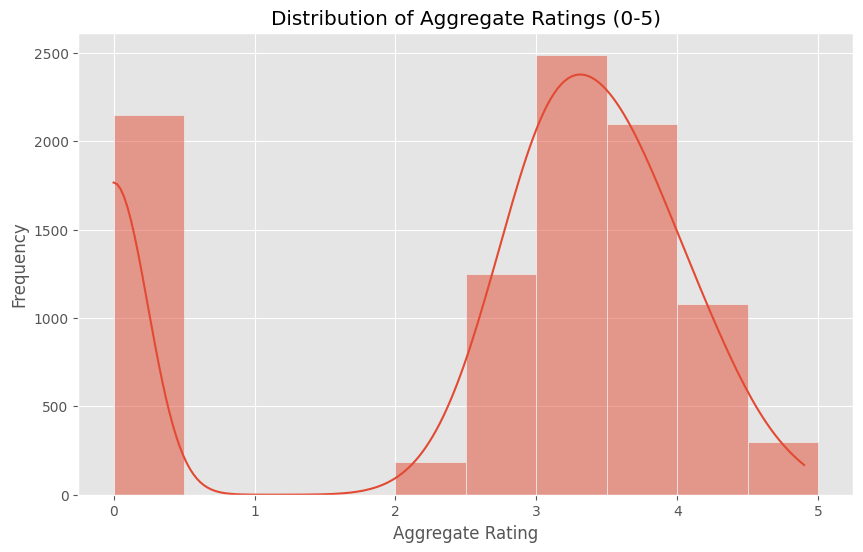

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Aggregate rating'], bins=10, kde=True, binrange=(0, 5))
plt.title('Distribution of Aggregate Ratings (0-5)')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

Question 2.Calculate the average number of votes
received by restaurants

In [27]:
average_votes = df['Votes'].mean()
print("Average number of votes:", average_votes)

Average number of votes: 156.909747670401


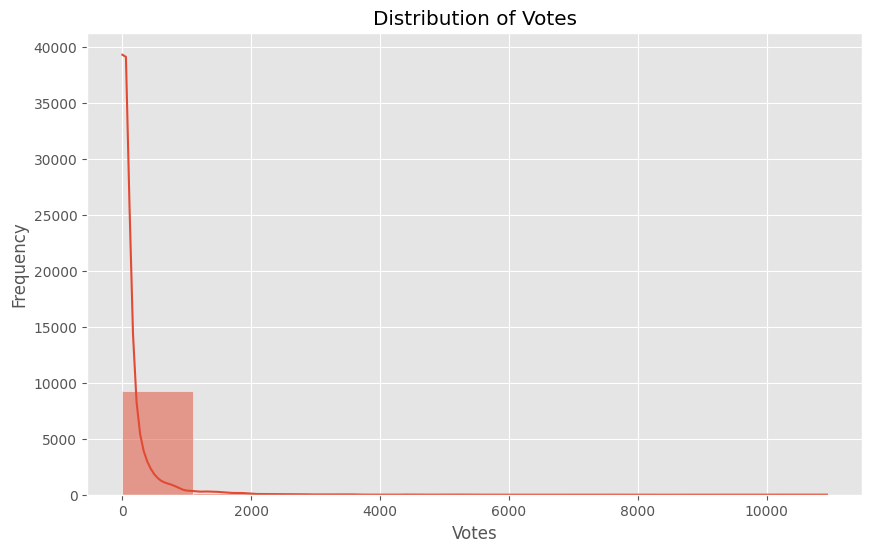

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Votes'], bins=10, kde=True)
plt.title('Distribution of Votes')
plt.xlabel('Votes')
plt.ylabel('Frequency')
plt.show()

Task 2: Cuisine Combination


The most common combinations of
cuisines in the dataset

In [19]:
most_common_cuisines_combination = df['Cuisines'].value_counts().head(3)
print(most_common_cuisines_combination)

Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64


Text(0, 0.5, 'Cuisine')

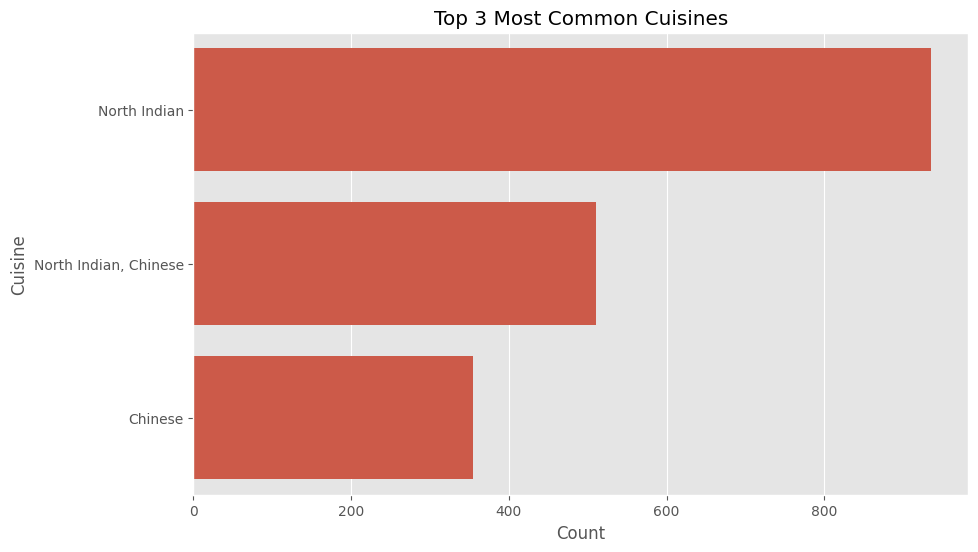

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Cuisines', data=df, order=df['Cuisines'].value_counts().index[:3])
plt.title('Top 3 Most Common Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')

Q2. Determine if certain cuisine combinations
tend to have higher ratings

Cuisines
Burger, Bar Food, Steak         4.9
American, Burger, Grill         4.9
American, Caribbean, Seafood    4.9
Name: Aggregate rating, dtype: float64


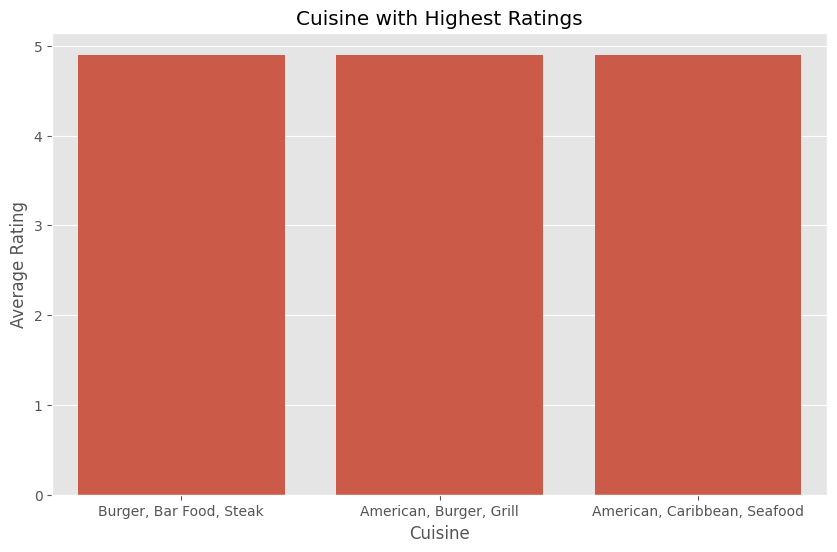

In [21]:
higher_rating_cuisine = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(3)
print(higher_rating_cuisine)
plt.figure(figsize=(10, 6))
sns.barplot(x=higher_rating_cuisine.index, y=higher_rating_cuisine.values)
plt.title('Cuisine with Highest Ratings')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.show()

Task 3 Geographic analysis.

Q1.  the locations of restaurants on a
map using longitude and latitude
coordinates.

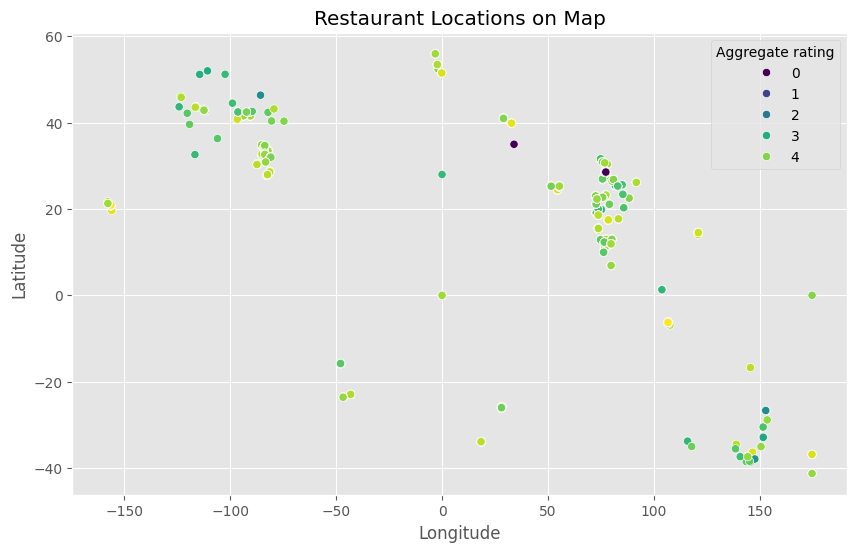

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', data=df, hue='Aggregate rating', palette='viridis')
plt.title('Restaurant Locations on Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Q2.  any patterns or clusters of
restaurants in specific areas

Locality
Connaught Place    122
Rajouri Garden      99
Shahdara            87
Name: Restaurant ID, dtype: int64


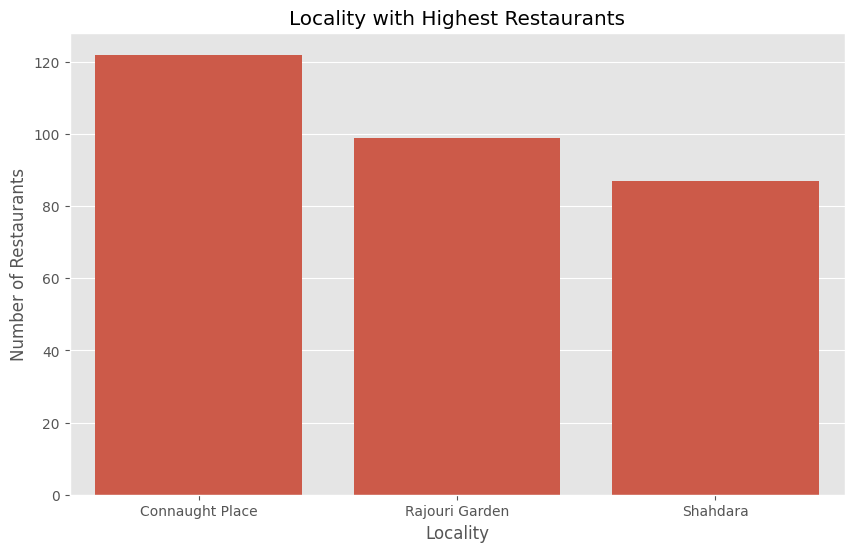

In [23]:
from re import Pattern
Pattern = df.groupby('Locality')['Restaurant ID'].count().sort_values(ascending=False).head(3)
print(Pattern)
plt.figure(figsize=(10, 6))
sns.barplot(x=Pattern.index, y=Pattern.values)
plt.title('Locality with Highest Restaurants')
plt.xlabel('Locality')
plt.ylabel('Number of Restaurants')
plt.show()

Task 4  Restarauent chain

---



Q1. Identify if there are any restaurant chains

> Add blockquote


present in the dataset

Restaurant Name
Cafe Coffee Day             83
Domino's Pizza              79
Subway                      63
Green Chick Chop            51
McDonald's                  48
                            ..
HotMess                      1
Healthy Routes               1
Fuji Japanese Restaurant     1
Fa Yian                      1
Unplugged Courtyard          1
Name: count, Length: 7446, dtype: int64


Text(0, 0.5, 'Number of Restaurants')

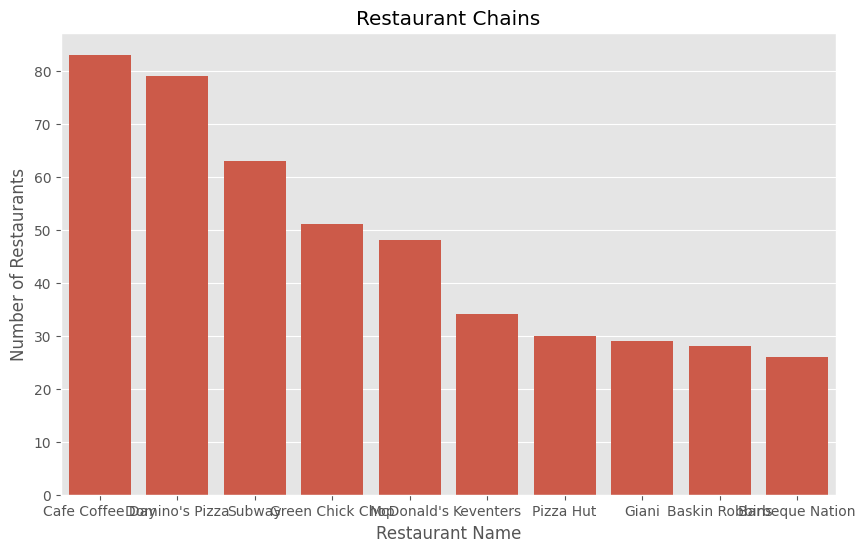

In [24]:
restaurant_chains = df['Restaurant Name'].value_counts()
print(restaurant_chains)
plt.figure(figsize=(10, 6))
sns.barplot(x=restaurant_chains.index[:10], y=restaurant_chains.values[:10])
plt.title('Restaurant Chains')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Restaurants')

Q2.the ratings and popularity of
different restaurant chains

Popular Restaurant Chains by Votes:
Restaurant Name
Barbeque Nation              28142
AB's - Absolute Barbecues    13400
Toit                         10934
Name: Votes, dtype: int64

Average Aggregate Rating for Popular Restaurant Chains:
Restaurant Name
Barbeque Nation              4.353846
AB's - Absolute Barbecues    4.825000
Toit                         4.800000
Name: Aggregate rating, dtype: float64


/tmp/ipython-input-1813308668.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_restaurant_chains_ratings.index, y=popular_restaurant_chains_ratings.values, palette='viridis')


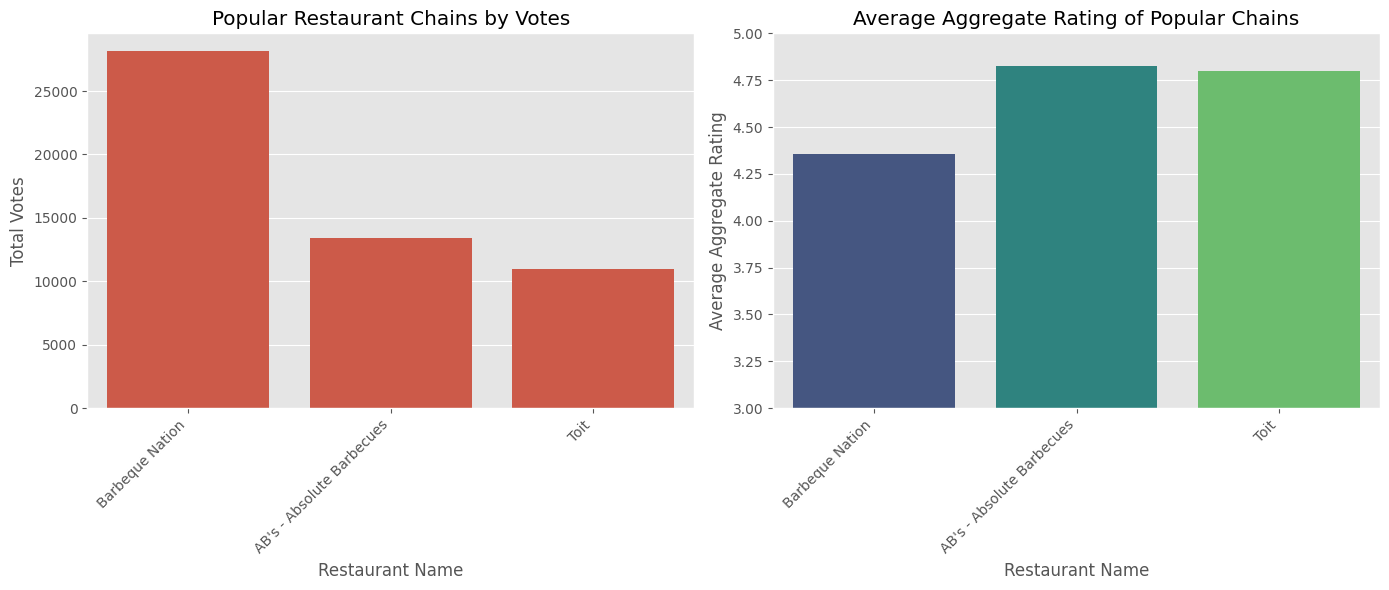

In [25]:
popular_restaurant_chains_votes = df.groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=False).head(3)
print("Popular Restaurant Chains by Votes:")
print(popular_restaurant_chains_votes)

top_chain_names = popular_restaurant_chains_votes.index

popular_restaurant_chains_ratings = df[df['Restaurant Name'].isin(top_chain_names)].groupby('Restaurant Name')['Aggregate rating'].mean().loc[top_chain_names]
print("\nAverage Aggregate Rating for Popular Restaurant Chains:")
print(popular_restaurant_chains_ratings)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=popular_restaurant_chains_votes.index, y=popular_restaurant_chains_votes.values)
plt.title('Popular Restaurant Chains by Votes')
plt.xlabel('Restaurant Name')
plt.ylabel('Total Votes')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=popular_restaurant_chains_ratings.index, y=popular_restaurant_chains_ratings.values, palette='viridis')
plt.title('Average Aggregate Rating of Popular Chains')
plt.xlabel('Restaurant Name')
plt.ylabel('Average Aggregate Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(3.0, 5.0)

plt.tight_layout()
plt.show()